In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
import matplotlib.pyplot as plt
import torch
import numpy as np
import random
from scipy.stats import ttest_1samp

from ProEmb.engines.trainer import Trainer
from ProEmb.engines.inference import Inferencer

# Dataset preprocessing

## Pro-Europe

In [ ]:
# Parameters
TEXT_COLUMN = 'translatedContentText'
USER_COLUMN = 'twitterData.twitterAuthorScreenname'
TIME_COLUMN = 'timePublished'
RETWEET_COLUMN = 'is_retweet'
TARGET_COLUMN = 'pro-Europe' 
EMOTION_COLS = [
    'Admiration', 'Anger', 'Approval', 'Curiosity', 'Disgust', 'Fear',
    'Joy', 'Love', 'Optimism', 'Pessimism', 'Sadness'
]

OTHER_COLS = ['twitterData.engagementType', 'twitterData.tweetId', 'twitterData.engagementParentId']

df = pd.read_csv("..dataset/moldova.csv", parse_dates=[TIME_COLUMN])
df = df[df['mediaType'] == 'Twitter']

# Filter and preprocess
columns_needed = [USER_COLUMN, TIME_COLUMN, TEXT_COLUMN, RETWEET_COLUMN, TARGET_COLUMN] + EMOTION_COLS + OTHER_COLS
df = df[columns_needed].dropna()

df[TARGET_COLUMN] = df[TARGET_COLUMN].map({'yes': 1, 'no': 0, True: 1, False: 0}).astype(int)
# Build ego-peer influence mapping: who retweeted whom
df_retweets = df[df['is_retweet']].copy()
tweet_id_to_author = df.set_index('twitterData.tweetId')[USER_COLUMN].to_dict()
df_retweets['ego'] = df_retweets[USER_COLUMN]  # the retweeter
df_retweets['peer'] = df_retweets['twitterData.engagementParentId'].map(tweet_id_to_author)
df_retweets = df_retweets.dropna(subset=['peer'])

# Group tweets by user
user_tweets = df.groupby(USER_COLUMN).apply(lambda x: x.sort_values(by=TIME_COLUMN)).reset_index(drop=True)

# Construct ego-peer-treatment-outcome dataset
data = []

# Build a fast lookup of user -> (time, pro-Europe, emotions, text)
user_posts = defaultdict(list)
for _, row in df.iterrows():
    user_posts[row[USER_COLUMN]].append((row[TIME_COLUMN], row[TARGET_COLUMN], row[EMOTION_COLS].values, row[TEXT_COLUMN]))

# Set up vectorizer for BoW encoding
vectorizer = CountVectorizer(max_features=1000)
vectorizer.fit(df[TEXT_COLUMN].tolist())


# Iterate over each ego
for ego, ego_rows in user_tweets.groupby(USER_COLUMN):
    # Find peers this ego retweeted in the past (i.e., their influencers)
    peers = df_retweets[df_retweets['ego'] == ego]['peer'].unique()
    if len(peers) == 0:
        continue

    for _, ego_row in ego_rows.iterrows():
        ego_time = ego_row[TIME_COLUMN]
        ego_outcome = int(ego_row[TARGET_COLUMN])

        # Peer treatment and feature aggregation
        treated = 0
        peer_texts = []
        peer_emotions = []

        for peer in peers:
            for t, pro_russia, emotions, text in user_posts.get(peer, []):
                if t < ego_time:
                    peer_texts.append(text)
                    peer_emotions.append(emotions)
                    if pro_russia:
                        treated = 1

        if not peer_texts:
            continue

        # Vectorize NCO and NCE features
        ego_vec_text = vectorizer.transform([ego_row[TEXT_COLUMN]]).toarray().flatten()
        ego_vec_emotions = ego_row[EMOTION_COLS].values.astype(float)
        ego_feat = np.concatenate([ego_vec_text, ego_vec_emotions])

        peer_vec_text = vectorizer.transform([" ".join(peer_texts)]).toarray().flatten()
        peer_vec_emotions = np.mean(np.array(peer_emotions), axis=0)
        peer_feat = np.concatenate([peer_vec_text, peer_vec_emotions])

        # Final row
        row = np.concatenate([ego_feat, peer_feat, [treated, ego_outcome]])
        data.append(row)

# Save converted dataset
n_emo = len(EMOTION_COLS)
columns = [f"ego_feat{i}" for i in range(1000 + n_emo)] + \
          [f"ngb_feat{i}" for i in range(1000 + n_emo)] + ["treatment", "outcome"]
df_out = pd.DataFrame(data, columns=columns)
df_out.to_csv("proemb_ready_moldova_pro-Europe.csv", index=False)

## anti-Europe

In [ ]:
# Parameters
TEXT_COLUMN = 'translatedContentText'
USER_COLUMN = 'twitterData.twitterAuthorScreenname'
TIME_COLUMN = 'timePublished'
RETWEET_COLUMN = 'is_retweet'
TARGET_COLUMN = 'anti-Europe' 
EMOTION_COLS = [
    'Admiration', 'Anger', 'Approval', 'Curiosity', 'Disgust', 'Fear',
    'Joy', 'Love', 'Optimism', 'Pessimism', 'Sadness'
]

OTHER_COLS = ['twitterData.engagementType', 'twitterData.tweetId', 'twitterData.engagementParentId']

df = pd.read_csv("..dataset/moldova.csv", parse_dates=[TIME_COLUMN])
df = df[df['mediaType'] == 'Twitter']

# Filter and preprocess
columns_needed = [USER_COLUMN, TIME_COLUMN, TEXT_COLUMN, RETWEET_COLUMN, TARGET_COLUMN] + EMOTION_COLS + OTHER_COLS
df = df[columns_needed].dropna()

df[TARGET_COLUMN] = df[TARGET_COLUMN].map({'yes': 1, 'no': 0, True: 1, False: 0}).astype(int)
# Build ego-peer influence mapping: who retweeted whom
df_retweets = df[df['is_retweet']].copy()
tweet_id_to_author = df.set_index('twitterData.tweetId')[USER_COLUMN].to_dict()
df_retweets['ego'] = df_retweets[USER_COLUMN]  # the retweeter
df_retweets['peer'] = df_retweets['twitterData.engagementParentId'].map(tweet_id_to_author)
df_retweets = df_retweets.dropna(subset=['peer'])

# Group tweets by user
user_tweets = df.groupby(USER_COLUMN).apply(lambda x: x.sort_values(by=TIME_COLUMN)).reset_index(drop=True)

# Construct ego-peer-treatment-outcome dataset
data = []

# Build a fast lookup of user -> (time, anti-Europe, emotions, text)
user_posts = defaultdict(list)
for _, row in df.iterrows():
    user_posts[row[USER_COLUMN]].append((row[TIME_COLUMN], row[TARGET_COLUMN], row[EMOTION_COLS].values, row[TEXT_COLUMN]))

# Set up vectorizer for BoW encoding
vectorizer = CountVectorizer(max_features=1000)
vectorizer.fit(df[TEXT_COLUMN].tolist())


# Iterate over each ego
for ego, ego_rows in user_tweets.groupby(USER_COLUMN):
    # Find peers this ego retweeted in the past (i.e., their influencers)
    peers = df_retweets[df_retweets['ego'] == ego]['peer'].unique()
    if len(peers) == 0:
        continue

    for _, ego_row in ego_rows.iterrows():
        ego_time = ego_row[TIME_COLUMN]
        ego_outcome = int(ego_row[TARGET_COLUMN])

        # Peer treatment and feature aggregation
        treated = 0
        peer_texts = []
        peer_emotions = []

        for peer in peers:
            for t, pro_russia, emotions, text in user_posts.get(peer, []):
                if t < ego_time:
                    peer_texts.append(text)
                    peer_emotions.append(emotions)
                    if pro_russia:
                        treated = 1

        if not peer_texts:
            continue

        # Vectorize NCO and NCE features
        ego_vec_text = vectorizer.transform([ego_row[TEXT_COLUMN]]).toarray().flatten()
        ego_vec_emotions = ego_row[EMOTION_COLS].values.astype(float)
        ego_feat = np.concatenate([ego_vec_text, ego_vec_emotions])

        peer_vec_text = vectorizer.transform([" ".join(peer_texts)]).toarray().flatten()
        peer_vec_emotions = np.mean(np.array(peer_emotions), axis=0)
        peer_feat = np.concatenate([peer_vec_text, peer_vec_emotions])

        # Final row
        row = np.concatenate([ego_feat, peer_feat, [treated, ego_outcome]])
        data.append(row)

# Save converted dataset
n_emo = len(EMOTION_COLS)
columns = [f"ego_feat{i}" for i in range(1000 + n_emo)] + \
          [f"ngb_feat{i}" for i in range(1000 + n_emo)] + ["treatment", "outcome"]
df_out = pd.DataFrame(data, columns=columns)
df_out.to_csv("proemb_ready_moldova_anti-Europe.csv", index=False)

## pro-Russia

In [ ]:
# Parameters
TEXT_COLUMN = 'translatedContentText'
USER_COLUMN = 'twitterData.twitterAuthorScreenname'
TIME_COLUMN = 'timePublished'
RETWEET_COLUMN = 'is_retweet'
TARGET_COLUMN = 'pro-Russia' 
EMOTION_COLS = [
    'Admiration', 'Anger', 'Approval', 'Curiosity', 'Disgust', 'Fear',
    'Joy', 'Love', 'Optimism', 'Pessimism', 'Sadness'
]

OTHER_COLS = ['twitterData.engagementType', 'twitterData.tweetId', 'twitterData.engagementParentId']

df = pd.read_csv("..dataset/moldova.csv", parse_dates=[TIME_COLUMN])
df = df[df['mediaType'] == 'Twitter']

# Filter and preprocess
columns_needed = [USER_COLUMN, TIME_COLUMN, TEXT_COLUMN, RETWEET_COLUMN, TARGET_COLUMN] + EMOTION_COLS + OTHER_COLS
df = df[columns_needed].dropna()

df[TARGET_COLUMN] = df[TARGET_COLUMN].map({'yes': 1, 'no': 0, True: 1, False: 0}).astype(int)
# Build ego-peer influence mapping: who retweeted whom
df_retweets = df[df['is_retweet']].copy()
tweet_id_to_author = df.set_index('twitterData.tweetId')[USER_COLUMN].to_dict()
df_retweets['ego'] = df_retweets[USER_COLUMN]  # the retweeter
df_retweets['peer'] = df_retweets['twitterData.engagementParentId'].map(tweet_id_to_author)
df_retweets = df_retweets.dropna(subset=['peer'])

# Group tweets by user
user_tweets = df.groupby(USER_COLUMN).apply(lambda x: x.sort_values(by=TIME_COLUMN)).reset_index(drop=True)

# Construct ego-peer-treatment-outcome dataset
data = []

# Build a fast lookup of user -> (time, pro-Russia, emotions, text)
user_posts = defaultdict(list)
for _, row in df.iterrows():
    user_posts[row[USER_COLUMN]].append((row[TIME_COLUMN], row[TARGET_COLUMN], row[EMOTION_COLS].values, row[TEXT_COLUMN]))

# Set up vectorizer for BoW encoding
vectorizer = CountVectorizer(max_features=1000)
vectorizer.fit(df[TEXT_COLUMN].tolist())


# Iterate over each ego
for ego, ego_rows in user_tweets.groupby(USER_COLUMN):
    # Find peers this ego retweeted in the past (i.e., their influencers)
    peers = df_retweets[df_retweets['ego'] == ego]['peer'].unique()
    if len(peers) == 0:
        continue

    for _, ego_row in ego_rows.iterrows():
        ego_time = ego_row[TIME_COLUMN]
        ego_outcome = int(ego_row[TARGET_COLUMN])

        # Peer treatment and feature aggregation
        treated = 0
        peer_texts = []
        peer_emotions = []

        for peer in peers:
            for t, pro_russia, emotions, text in user_posts.get(peer, []):
                if t < ego_time:
                    peer_texts.append(text)
                    peer_emotions.append(emotions)
                    if pro_russia:
                        treated = 1

        if not peer_texts:
            continue

        # Vectorize NCO and NCE features
        ego_vec_text = vectorizer.transform([ego_row[TEXT_COLUMN]]).toarray().flatten()
        ego_vec_emotions = ego_row[EMOTION_COLS].values.astype(float)
        ego_feat = np.concatenate([ego_vec_text, ego_vec_emotions])

        peer_vec_text = vectorizer.transform([" ".join(peer_texts)]).toarray().flatten()
        peer_vec_emotions = np.mean(np.array(peer_emotions), axis=0)
        peer_feat = np.concatenate([peer_vec_text, peer_vec_emotions])

        # Final row
        row = np.concatenate([ego_feat, peer_feat, [treated, ego_outcome]])
        data.append(row)

# Save converted dataset
n_emo = len(EMOTION_COLS)
columns = [f"ego_feat{i}" for i in range(1000 + n_emo)] + \
          [f"ngb_feat{i}" for i in range(1000 + n_emo)] + ["treatment", "outcome"]
df_out = pd.DataFrame(data, columns=columns)
df_out.to_csv("proemb_ready_moldova_pro-Russia.csv", index=False)

## anti-Russia

In [ ]:
# Parameters
TEXT_COLUMN = 'translatedContentText'
USER_COLUMN = 'twitterData.twitterAuthorScreenname'
TIME_COLUMN = 'timePublished'
RETWEET_COLUMN = 'is_retweet'
TARGET_COLUMN = 'anti-Russia' 
EMOTION_COLS = [
    'Admiration', 'Anger', 'Approval', 'Curiosity', 'Disgust', 'Fear',
    'Joy', 'Love', 'Optimism', 'Pessimism', 'Sadness'
]

OTHER_COLS = ['twitterData.engagementType', 'twitterData.tweetId', 'twitterData.engagementParentId']

df = pd.read_csv("..dataset/moldova.csv", parse_dates=[TIME_COLUMN])
df = df[df['mediaType'] == 'Twitter']

# Filter and preprocess
columns_needed = [USER_COLUMN, TIME_COLUMN, TEXT_COLUMN, RETWEET_COLUMN, TARGET_COLUMN] + EMOTION_COLS + OTHER_COLS
df = df[columns_needed].dropna()

df[TARGET_COLUMN] = df[TARGET_COLUMN].map({'yes': 1, 'no': 0, True: 1, False: 0}).astype(int)
# Build ego-peer influence mapping: who retweeted whom
df_retweets = df[df['is_retweet']].copy()
tweet_id_to_author = df.set_index('twitterData.tweetId')[USER_COLUMN].to_dict()
df_retweets['ego'] = df_retweets[USER_COLUMN]  # the retweeter
df_retweets['peer'] = df_retweets['twitterData.engagementParentId'].map(tweet_id_to_author)
df_retweets = df_retweets.dropna(subset=['peer'])

# Group tweets by user
user_tweets = df.groupby(USER_COLUMN).apply(lambda x: x.sort_values(by=TIME_COLUMN)).reset_index(drop=True)

# Construct ego-peer-treatment-outcome dataset
data = []

# Build a fast lookup of user -> (time, anti-Russia, emotions, text)
user_posts = defaultdict(list)
for _, row in df.iterrows():
    user_posts[row[USER_COLUMN]].append((row[TIME_COLUMN], row[TARGET_COLUMN], row[EMOTION_COLS].values, row[TEXT_COLUMN]))

# Set up vectorizer for BoW encoding
vectorizer = CountVectorizer(max_features=1000)
vectorizer.fit(df[TEXT_COLUMN].tolist())


# Iterate over each ego
for ego, ego_rows in user_tweets.groupby(USER_COLUMN):
    # Find peers this ego retweeted in the past (i.e., their influencers)
    peers = df_retweets[df_retweets['ego'] == ego]['peer'].unique()
    if len(peers) == 0:
        continue

    for _, ego_row in ego_rows.iterrows():
        ego_time = ego_row[TIME_COLUMN]
        ego_outcome = int(ego_row[TARGET_COLUMN])

        # Peer treatment and feature aggregation
        treated = 0
        peer_texts = []
        peer_emotions = []

        for peer in peers:
            for t, pro_russia, emotions, text in user_posts.get(peer, []):
                if t < ego_time:
                    peer_texts.append(text)
                    peer_emotions.append(emotions)
                    if pro_russia:
                        treated = 1

        if not peer_texts:
            continue

        # Vectorize NCO and NCE features
        ego_vec_text = vectorizer.transform([ego_row[TEXT_COLUMN]]).toarray().flatten()
        ego_vec_emotions = ego_row[EMOTION_COLS].values.astype(float)
        ego_feat = np.concatenate([ego_vec_text, ego_vec_emotions])

        peer_vec_text = vectorizer.transform([" ".join(peer_texts)]).toarray().flatten()
        peer_vec_emotions = np.mean(np.array(peer_emotions), axis=0)
        peer_feat = np.concatenate([peer_vec_text, peer_vec_emotions])

        # Final row
        row = np.concatenate([ego_feat, peer_feat, [treated, ego_outcome]])
        data.append(row)

# Save converted dataset
n_emo = len(EMOTION_COLS)
columns = [f"ego_feat{i}" for i in range(1000 + n_emo)] + \
          [f"ngb_feat{i}" for i in range(1000 + n_emo)] + ["treatment", "outcome"]
df_out = pd.DataFrame(data, columns=columns)
df_out.to_csv("proemb_ready_moldova_anti-Russia.csv", index=False)

# ProEmb pipeline

In [ ]:
EMOTION_COLS = [
    'Admiration', 'Anger', 'Approval', 'Curiosity', 'Disgust', 'Fear',
    'Joy', 'Love', 'Optimism', 'Pessimism', 'Sadness'
]

n_emo = len(EMOTION_COLS)

# Reproducibility
def set_seeds(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def run_proemb_pipeline(
    csv_path: str,
    ego_cols,
    ngb_cols,
    treat_col: str,
    outcome_col: str,
    latent_dim: int = 32,
    embed_epochs: int = 100,
    outcome_epochs: int = 100,
    seed: int = 0,
):
    set_seeds(seed)

    input_dim = len(ego_cols) + len(ngb_cols)

    trainer = Trainer(
        input_dim=input_dim,
        latent_dim=latent_dim,
        encoder_hidden=[100, 100, 100],
        decoder_hidden=[100, 100, 100],
        disc_hidden=[100, 100, 100, 100],
        base_model="lightgbm",
        base_hidden=[125, 125],
        batch_size=64,
        lr_vae=1e-3,
        lr_disc=1e-3,
    )

    dataset = trainer.load_data(
        csv_path=csv_path,
        ego_proxy_cols=ego_cols,
        ngb_proxy_cols=ngb_cols,
        treat_col=treat_col,
        outcome_col=outcome_col,
    )

    trainer.train_all(dataset, embed_epochs=embed_epochs, outcome_epochs=outcome_epochs)
    encoder, decoder, discriminator, meta_learner = trainer.get_trained_components()

    inferencer = Inferencer(encoder, meta_learner)
    results = inferencer.infer_from_csv(
        csv_path,
        ego_proxy_cols=ego_cols,
        ngb_proxy_cols=ngb_cols,
    )

    ites = results["ite"]
    ace = results["ace"].item()
    _, pval = ttest_1samp(ites, popmean=0)

    return {"ites": ites, "ace": ace, "pval": pval}


n_text = 384
EGO_COLS = [f"ego_feat{i}" for i in range(n_text + n_emo)]
NGB_COLS = [f"ngb_feat{i}" for i in range(n_text + n_emo)]
TREAT_COL = "treatment"
OUTCOME_COL = "outcome"

STANCE_FILES = {
    "pro-Europe":  "proemb_ready_moldova_pro-Europe.csv",
    "pro-Russia":  "proemb_ready_moldova_pro-Russia.csv",
    "anti-Europe": "proemb_ready_moldova_anti-Europe.csv",
    "anti-Russia": "proemb_ready_moldova_anti-Russia.csv",
}

N_RUNS = 10
SEEDS = list(range(N_RUNS))

results_by_stance = {}

for stance, path in STANCE_FILES.items():
    print(f"\n[INFO] Repeated training + inference for {stance} ({path})")

    run_records = []
    for seed in SEEDS:
        out = run_proemb_pipeline(
            csv_path=path,
            ego_cols=EGO_COLS,
            ngb_cols=NGB_COLS,
            treat_col=TREAT_COL,
            outcome_col=OUTCOME_COL,
            embed_epochs=100,
            outcome_epochs=100,
            seed=seed,
        )
        run_records.append(out)

    # Store all run-level outputs
    aces = np.array([r["ace"] for r in run_records], dtype=float)
    pvals = np.array([r["pval"] for r in run_records], dtype=float)

    results_by_stance[stance] = {
        "runs": run_records,                 
        "aces": aces,                        
        "ace_mean": float(aces.mean()),
        "ace_std": float(aces.std(ddof=1)) if len(aces) > 1 else 0.0,
        "pvals": pvals,
        "ites_first": run_records[0]["ites"],
    }

In [ ]:
for stance in results_by_stance:
        print(
        f"[INFO] {stance}: ACE mean={results_by_stance[stance]['ace_mean']:.4f}, "
        f"std={results_by_stance[stance]['ace_std']:.4f}"
        f"median p-value= {np.median(results_by_stance[stance]['pvals'])}"
    )

[INFO] pro-Europe: ACE mean=0.2179, std=0.0345median p-value= 1.8230891890440828e-60
[INFO] pro-Russia: ACE mean=0.5168, std=0.0002median p-value= 0.0
[INFO] anti-Europe: ACE mean=0.2511, std=0.0431median p-value= 1.8044328524633003e-147
[INFO] anti-Russia: ACE mean=0.2532, std=0.0209median p-value= 1.1519523454845727e-78


# ITE distribution

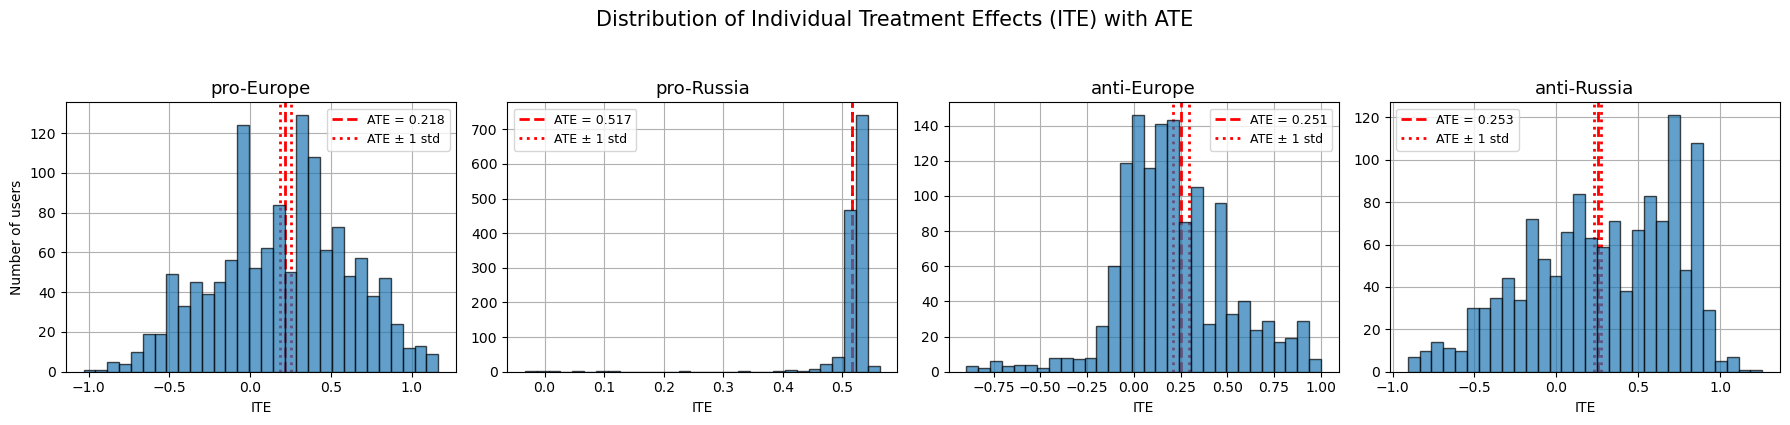

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)


for ax, stance in zip(axes, STANCE_FILES.keys()):
    stance_res = results_by_stance[stance]

    ites = stance_res["ites_one_run"]    
    ace_mean = stance_res["ace_mean"]
    ace_std  = stance_res["ace_std"]


    ax.hist(ites, bins=30, edgecolor="black", alpha=0.7, zorder=3)
    
    ax.axvline(ace_mean, color="red", linestyle="--", linewidth=2, label=f"ATE = {ace_mean:.3f}")

    # +/- 1 std of ACE across runs
    ax.axvline(ace_mean - ace_std, color="red", linestyle=":", linewidth=2, label="ATE ± 1 std")
    ax.axvline(ace_mean + ace_std, color="red", linestyle=":", linewidth=2)

    ax.set_title(f"{stance}", fontsize=13)
    ax.set_xlabel("ITE")
    ax.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(loc="best", fontsize=9)

axes[0].set_ylabel("Number of users")
# fig.suptitle("Distribution of Individual Treatment Effects (ITE) with ATE", y=1.05, fontsize=15)

plt.tight_layout()
plt.show()
